# EndoScan AI — MRI Branch
> *Detecting endometriosis from pelvic MRI scans using EfficientNet-B0 fine-tuning.*

---

## CRISP-DM Roadmap

| Phase | Description | Status |
|---|---|---|
| 1. Business Understanding | Same as laparoscopy notebook — MRI is second modality | ✅ Defined |
| 2. Data Understanding | Load UT-EndoMRI, inspect NIfTI volumes, count positives/negatives | ← We are here |
| 3. Data Preparation | Extract 2D slices, normalise, patient-level split, augmentation |
| 4. Modelling | EfficientNet-B0 single-channel fine-tuning |
| 5. Evaluation | AUC, sensitivity, specificity, Grad-CAM |
| 6. Deployment | Gemini explanation layer + fusion with laparoscopy router |

---
# Phase 2 — Data Understanding

**Dataset:** UT-EndoMRI (UTHealth Endometriosis MRI Dataset)  
**Source:** Zenodo — DOI 10.5281/zenodo.13749613  
**License:** CC BY-NC 4.0 — non-commercial research only  
**Format:** NIfTI (.nii) — 3D volumetric MRI scans  

**Key difference from laparoscopy:**
- Each 'image' is a 3D volume (dozens of slices stacked)
- We extract 2D slices and treat each slice as a training sample
- MRI is greyscale — no colour augmentation
- Labels come from segmentation masks, not COCO JSON
- Two institutions: D1_MHS (51 patients, 3 raters) and D2_TCPW (82 patients, 1 rater)

### Cell 1 — Imports

In [1]:
# Install nibabel for NIfTI file handling
!pip install nibabel -q

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter
import re
import json

print('All imports OK')
print(f'nibabel version: {nib.__version__}')

All imports OK
nibabel version: 5.4.2


### Cell 2 — Paths
> Update `MRI_ROOT` to wherever Zenodo downloaded the dataset.

In [2]:
# ── UPDATE THIS PATH ──────────────────────────────────────────────
MRI_ROOT = Path.home() / 'Downloads' / 'UT-EndoMRI'
# ─────────────────────────────────────────────────────────────────

D1_DIR = MRI_ROOT / 'D1_MHS'
D2_DIR = MRI_ROOT / 'D2_TCPW'

assert MRI_ROOT.exists(), f'Cannot find dataset at {MRI_ROOT}'
assert D1_DIR.exists(),   f'Cannot find D1_MHS at {D1_DIR}'
assert D2_DIR.exists(),   f'Cannot find D2_TCPW at {D2_DIR}'

print(f'MRI root : {MRI_ROOT}')
print(f'D1_MHS   : {D1_DIR}')
print(f'D2_TCPW  : {D2_DIR}')

MRI root : /home/joy/Downloads/UT-EndoMRI
D1_MHS   : /home/joy/Downloads/UT-EndoMRI/D1_MHS
D2_TCPW  : /home/joy/Downloads/UT-EndoMRI/D2_TCPW


### Cell 3 — Count patients and files

In [3]:
def scan_institution(inst_dir, raters=1):
    """
    Scan an institution folder and return a dict of patient info.
    Each patient folder contains NIfTI files for sequences and labels.
    """
    patients = {}
    for pt_dir in sorted(inst_dir.iterdir()):
        if not pt_dir.is_dir():
            continue

        pt_id = pt_dir.name
        files = list(pt_dir.glob('*.nii*'))

        # Categorise files
        seqs   = [f for f in files if any(
            f.stem.endswith(s) for s in ['_T1','_T2','_T1FS','_T2FS']
        )]
        labels = [f for f in files if '_em' in f.stem]  # endometrioma mask
        other  = [f for f in files if f not in seqs and f not in labels]

        patients[pt_id] = {
            'dir'        : pt_dir,
            'sequences'  : seqs,
            'em_labels'  : labels,
            'other_labels': other,
            'has_em'     : len(labels) > 0
        }

    return patients


d1_patients = scan_institution(D1_DIR, raters=3)
d2_patients = scan_institution(D2_DIR, raters=1)

d1_pos = sum(1 for p in d1_patients.values() if p['has_em'])
d2_pos = sum(1 for p in d2_patients.values() if p['has_em'])
d1_neg = len(d1_patients) - d1_pos
d2_neg = len(d2_patients) - d2_pos

print('=' * 50)
print('  UT-EndoMRI — Patient Count')
print('=' * 50)
print(f'  D1_MHS  : {len(d1_patients):3d} patients '
      f'({d1_pos} positive / {d1_neg} negative)')
print(f'  D2_TCPW : {len(d2_patients):3d} patients '
      f'({d2_pos} positive / {d2_neg} negative)')
print(f'  Total   : {len(d1_patients)+len(d2_patients):3d} patients '
      f'({d1_pos+d2_pos} positive / {d1_neg+d2_neg} negative)')
print('=' * 50)

  UT-EndoMRI — Patient Count
  D1_MHS  :  50 patients (40 positive / 10 negative)
  D2_TCPW :  49 patients (11 positive / 38 negative)
  Total   :  99 patients (51 positive / 48 negative)


### Cell 4 — Inspect one NIfTI volume
NIfTI files are 3D arrays — width × height × slices.
We need to understand the shape before extracting 2D slices.

In [4]:
# Pick first patient from D1 that has a T2 sequence
sample_pt = None
for pt_id, info in d1_patients.items():
    t2_files = [f for f in info['sequences'] if '_T2' in f.stem
                and '_T2FS' not in f.stem]
    if t2_files:
        sample_pt  = info
        sample_t2  = t2_files[0]
        break

# Load the volume
vol     = nib.load(sample_t2)
vol_arr = vol.get_fdata()

print(f'Patient      : {sample_t2.parent.name}')
print(f'File         : {sample_t2.name}')
print(f'Volume shape : {vol_arr.shape}  (W × H × Slices)')
print(f'Voxel size   : {vol.header.get_zooms()}')
print(f'Data type    : {vol_arr.dtype}')
print(f'Intensity range: [{vol_arr.min():.1f}, {vol_arr.max():.1f}]')
print(f'Number of slices: {vol_arr.shape[2]}')

Patient      : D1-000
File         : D1-000_T2.nii
Volume shape : (480, 480, 32)  (W × H × Slices)
Voxel size   : (0.5, 0.5, 4.9999995)
Data type    : float64
Intensity range: [0.0, 3960.0]
Number of slices: 32


### Cell 5 — Visualise slices from one volume

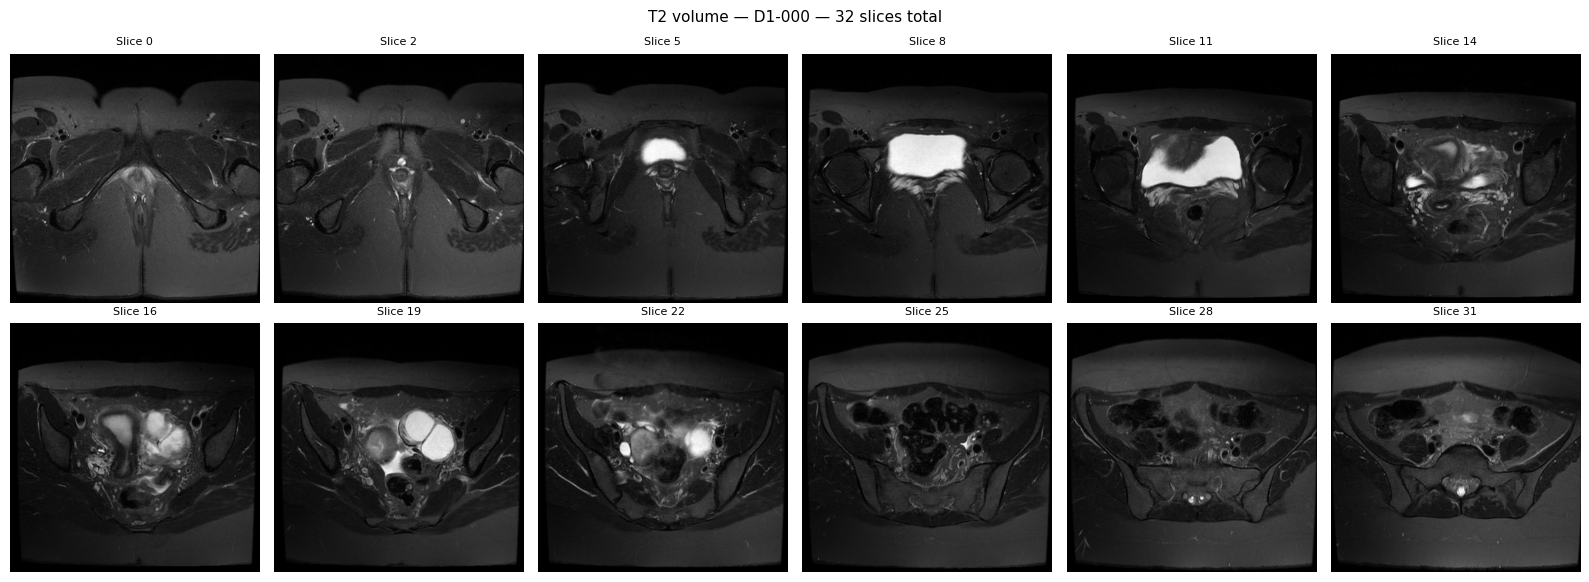

In [5]:
n_slices    = vol_arr.shape[2]
show_slices = np.linspace(0, n_slices-1, 12, dtype=int)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, idx in zip(axes.flatten(), show_slices):
    sl = vol_arr[:, :, idx]
    # Normalise for display
    sl_norm = (sl - sl.min()) / (sl.max() - sl.min() + 1e-8)
    ax.imshow(sl_norm.T, cmap='gray', origin='lower')
    ax.set_title(f'Slice {idx}', fontsize=8)
    ax.axis('off')

plt.suptitle(f'T2 volume — {sample_t2.parent.name} — {n_slices} slices total',
             fontsize=11)
plt.tight_layout()
plt.show()

### Cell 6 — Overlay endometrioma mask on T2 slices
For positive patients, the endometrioma (em) mask tells us
which slices contain lesions — these become label=1 slices.

T2 shape   : (480, 480, 32)
Mask shape : (480, 480, 32)
Mask unique values: [0. 1.]
Slices with endometrioma: [18, 19, 20, 21, 22, 23]


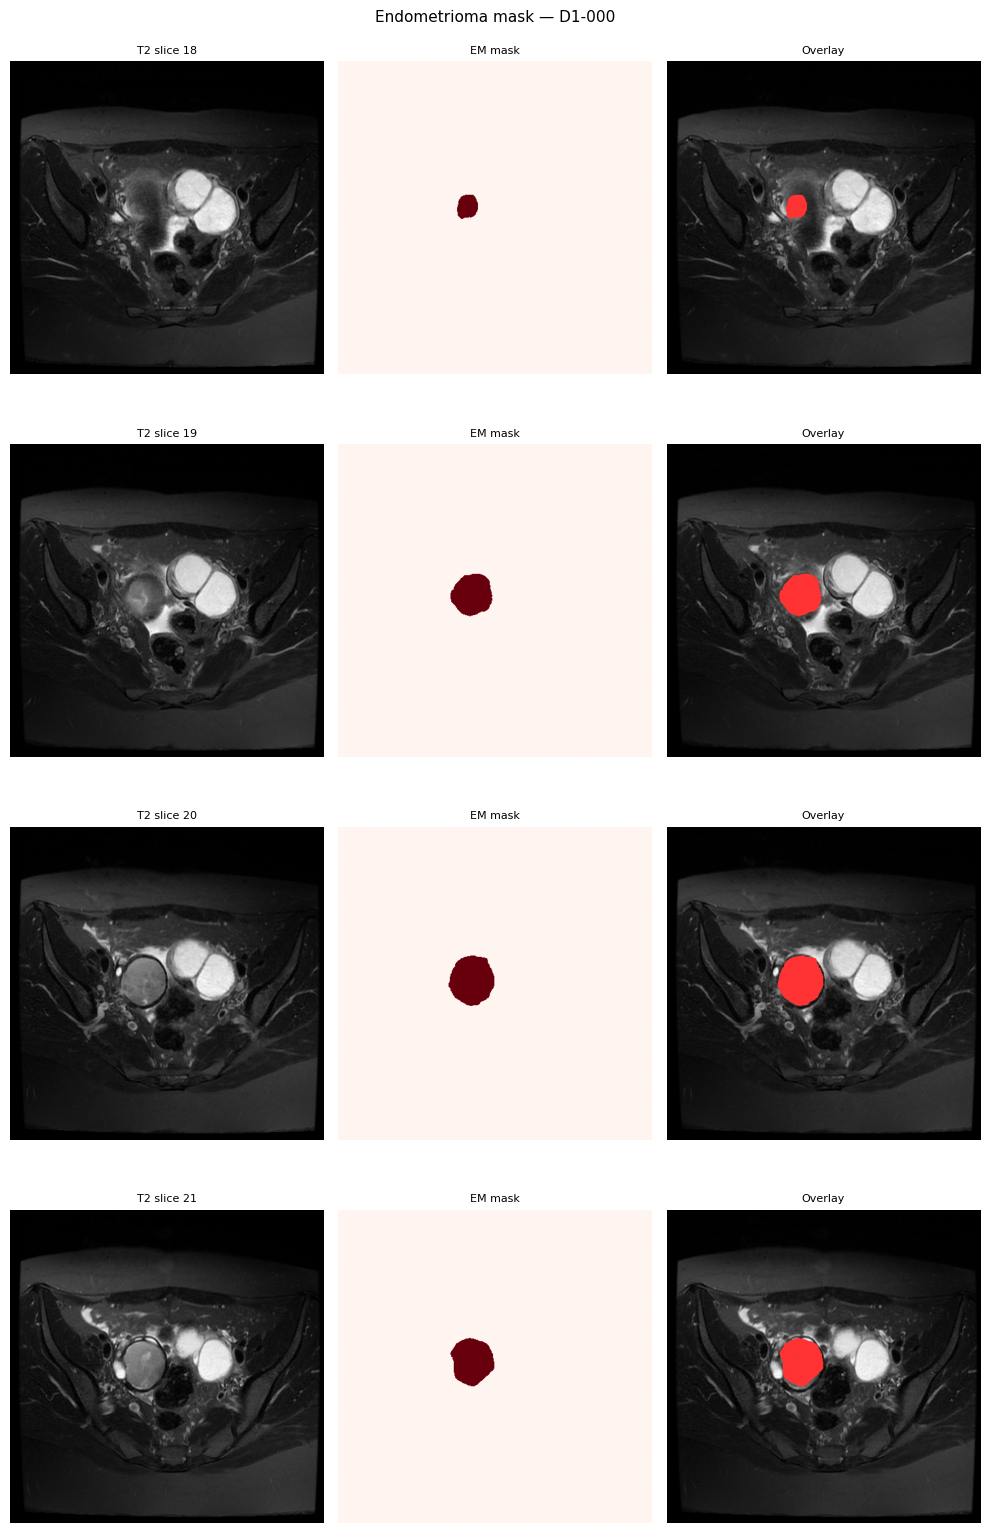

In [6]:
# Find a positive patient in D1 with both T2 and em label
pos_pt = None
for pt_id, info in d1_patients.items():
    t2_files = [f for f in info['sequences']
                if '_T2' in f.stem and '_T2FS' not in f.stem]
    em_files = [f for f in info['em_labels'] if '_r1' in f.stem]
    if t2_files and em_files:
        pos_pt    = info
        pos_t2    = t2_files[0]
        pos_em    = em_files[0]
        break

# Load both
t2_vol  = nib.load(pos_t2).get_fdata()
em_mask = nib.load(pos_em).get_fdata()

print(f'T2 shape   : {t2_vol.shape}')
print(f'Mask shape : {em_mask.shape}')
print(f'Mask unique values: {np.unique(em_mask)}')

# Find slices that contain endometrioma
positive_slices = [i for i in range(em_mask.shape[2])
                   if em_mask[:, :, i].max() > 0]
print(f'Slices with endometrioma: {positive_slices}')

# Visualise 4 positive slices with mask overlay
show = positive_slices[:4] if len(positive_slices) >= 4 else positive_slices

fig, axes = plt.subplots(len(show), 3, figsize=(10, 4*len(show)))
if len(show) == 1:
    axes = axes[np.newaxis, :]

for row, sl_idx in enumerate(show):
    t2_sl   = t2_vol[:, :, sl_idx]
    em_sl   = em_mask[:, :, sl_idx]
    t2_norm = (t2_sl - t2_sl.min()) / (t2_sl.max() - t2_sl.min() + 1e-8)

    # Overlay
    overlay      = np.stack([t2_norm]*3, axis=-1)
    overlay[em_sl > 0] = [1, 0.2, 0.2]  # red for lesion

    axes[row, 0].imshow(t2_norm.T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f'T2 slice {sl_idx}', fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(em_sl.T, cmap='Reds', origin='lower')
    axes[row, 1].set_title('EM mask', fontsize=8)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay.transpose(1, 0, 2), origin='lower')
    axes[row, 2].set_title('Overlay', fontsize=8)
    axes[row, 2].axis('off')

plt.suptitle(f'Endometrioma mask — {pos_t2.parent.name}', fontsize=11)
plt.tight_layout()
plt.show()

### Cell 7 — Data Understanding summary

In [ ]:
# Count total slices across all patients
total_slices     = 0
positive_slices_total = 0
all_patients     = {**d1_patients, **d2_patients}

for pt_id, info in all_patients.items():
    t2_files = [f for f in info['sequences']
                if '_T2' in f.stem and '_T2FS' not in f.stem]
    if not t2_files:
        continue

    try:
        vol          = nib.load(t2_files[0]).get_fdata()
        n_sl         = vol.shape[2]
        total_slices += n_sl

        if info['has_em'] and info['em_labels']:
            em = nib.load(info['em_labels'][0]).get_fdata()
            pos_sl = sum(1 for i in range(em.shape[2])
                        if em[:,:,i].max() > 0)
            positive_slices_total += pos_sl
    except:
        pass

print('=' * 55)
print('  DATA UNDERSTANDING SUMMARY — MRI')
print('=' * 55)
print(f'  Dataset          : UT-EndoMRI')
print(f'  Total patients   : {len(all_patients)}')
print(f'  Positive (has em): {d1_pos+d2_pos}')
print(f'  Negative (no em) : {d1_neg+d2_neg}')
print(f'  Primary sequence : T2-weighted (best for soft tissue)')
print(f'  Total T2 slices  : ~{total_slices}')
print(f'  Positive slices  : ~{positive_slices_total}')
print(f'  Negative slices  : ~{total_slices - positive_slices_total}')
print()
print('  Key differences from laparoscopy:')
print('  - 3D volumes, not 2D images')
print('  - Greyscale, not RGB')
print('  - Slice-level labels from segmentation masks')
print('  - Must split by patient, not by slice')
print('  - D1 has 3 raters — need consensus strategy')
print('=' * 55)

---
## ✅ Phase 2 — Data Understanding complete

**Phase 3 next — Data Preparation:**
- Choose T2 as primary sequence
- D1 rater consensus strategy (majority vote: 2-of-3)
- Extract 2D slices → label each as positive or negative
- Patient-level 70/15/15 split
- Intensity normalisation (z-score, not ImageNet stats)
- Augmentation (flips, rotations — no colour shifts)
- PyTorch Dataset + DataLoader